In [59]:
import glob
import numpy as np
import pandas as pd
from scipy import signal
from functools import reduce
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.stattools import omni_normtest
from bluemath_tk.distributions.nonstat_gev import NonStatGEV

In [60]:
def extract_number(filename):
    return int(''.join(filter(str.isdigit, filename)))

station_files = glob.glob('/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/*.parquet')
station_files.sort(key=extract_number)
print(station_files)

['/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_0.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_1.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_2.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_3.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_4.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_5.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_6.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_7.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_8.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_9.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_10.parquet', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/sksurge_parquets/station_11.parquet', '/home/aapolo

In [61]:
def run_regression(X, y):
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    
    dw_test = durbin_watson(model.resid)
    omnibus_stat, omnibus_p = omni_normtest(model.resid)
    
    return model, X_const, dw_test, omnibus_p, y

In [62]:
def check_normality(omnibus_p):
    if omnibus_p < 0.05:
        #print("Residuals not normal (Omnibus).")
        return False  # Residuals are not normal
    else:
        #print("Residuals appear normal (Omnibus).")
        return True  # Residuals are normal

In [63]:
def summarize_model(model, X_const):
    
    param_names = X_const.columns
    
    params = pd.Series(model.params, index=param_names)
    std_errors = pd.Series(model.bse, index=param_names)
    p_values = pd.Series(model.pvalues, index=param_names)

    summary = {
        'intercept': params['const'] if 'const' in param_names else np.nan,
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj, 
        'f_statistic': getattr(model, 'fvalue', np.nan),
        'f_pvalue': getattr(model, 'f_pvalue', np.nan),
        'model_summary': model.summary()
    }

    for name in params.index:
        if name != 'const':
            summary[f'slope_{name}'] = params[name]
            summary[f'p_value_{name}'] = p_values[name]
            summary[f'CI_{name}'] = std_errors[name] * 1.96
    return summary

In [64]:
one_station = station_files[1227] 
data = pd.read_parquet(one_station)

In [65]:
data["time_diff"] = (data["tide_time"] - data["surge_time"]).abs()

# For each surge_time, keep the row with the smallest difference
closest_rows = data.loc[data.groupby("surge_time")["time_diff"].idxmin()]
closest_rows = closest_rows.drop(columns="time_diff")
data = closest_rows
data


,tide_time,surge_time,station_x_coordinate,station_y_coordinate,stations,waterlevel,station_x_coordinate_tide,station_y_coordinate_tide,stations_tide,tide,skew_surge
0,1950-01-01 03:40:00,1950-01-01 00:20:00,-3.113,55.964,1227,1.500,-3.113,55.964,1227,0.039,1.461
1,1950-01-01 16:30:00,1950-01-01 13:00:00,-3.113,55.964,1227,1.410,-3.113,55.964,1227,0.412,0.998
2,1950-01-02 00:10:00,1950-01-02 01:30:00,-3.113,55.964,1227,1.821,-3.113,55.964,1227,0.372,1.449
3,1950-01-02 12:50:00,1950-01-02 13:40:00,-3.113,55.964,1227,1.827,-3.113,55.964,1227,1.075,0.752
4,1950-01-03 01:20:00,1950-01-03 02:00:00,-3.113,55.964,1227,1.866,-3.113,55.964,1227,1.451,0.415
...,...,...,...,...,...,...,...,...,...,...,...
52929,2024-12-30 02:20:00,2024-12-30 02:10:00,-3.113,55.964,1227,1.968,-3.113,55.964,1227,2.051,-0.083
52930,2024-12-30 14:40:00,2024-12-30 14:40:00,-3.113,55.964,1227,2.109,-3.113,55.964,1227,2.248,-0.139
52931,2024-12-31 03:00:00,2024-12-31 03:00:00,-3.113,55.964,1227,2.073,-3.113,55.964,1227,2.195,-0.122
52932,2024-12-31 15:20:00,2024-12-31 15:20:00,-3.113,55.964,1227,2.053,-3.113,55.964,1227,2.409,-0.356


In [66]:
data = data [['surge_time','skew_surge']]
data = data[~((data['surge_time'] >= '1950-01-01') & 
            (data['surge_time'] <= '1950-01-04'))]
data = data[~((data['surge_time'] >= '2021-03-09') & 
                    (data['surge_time'] < '2021-03-10'))]
data = data.reset_index(drop=True)

data['detrended_surge'] = signal.detrend(data['skew_surge'])
data['Year'] = data['surge_time'].dt.year
data.set_index("surge_time", inplace=True)
data

,skew_surge,detrended_surge,Year
surge_time,,,
1950-01-04 02:50:00,-0.342,-0.325207,1950
1950-01-04 15:10:00,0.449,0.465793,1950
1950-01-05 03:30:00,-0.215,-0.198207,1950
1950-01-05 15:40:00,0.224,0.240793,1950
1950-01-06 04:20:00,-0.260,-0.243207,1950
...,...,...,...
2024-12-30 02:10:00,-0.083,-0.060807,2024
2024-12-30 14:40:00,-0.139,-0.116807,2024
2024-12-31 03:00:00,-0.122,-0.099807,2024


In [67]:
Annual_max_idx = data.resample('YE')['detrended_surge'].idxmax()
#print(f"Annual_max_idx:\n{Annual_max_idx}")
Annual_max = data.loc[Annual_max_idx]
print (Annual_max)

                     skew_surge  detrended_surge  Year
surge_time                                            
1950-03-11 20:10:00       0.532         0.548806  1950
1951-12-24 23:20:00       0.600         0.616935  1951
1952-01-15 16:40:00       0.574         0.590939  1952
1953-01-31 16:10:00       0.535         0.552014  1953
1954-11-12 03:50:00       0.491         0.508142  1954
...                         ...              ...   ...
2020-01-15 05:30:00       0.696         0.717836  2020
2021-11-26 19:50:00       0.597         0.618970  2021
2022-02-21 05:50:00       0.514         0.535987  2022
2023-11-02 17:40:00       0.527         0.549109  2023
2024-01-22 12:20:00       0.641         0.663125  2024

[75 rows x 3 columns]


In [68]:
climate_files = sorted(glob.glob('/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/*.txt'))
print (climate_files)

['/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/AMM.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/AO.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/NaoJones.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/Nina1_anom.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/Nina3_4_anom.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/Nina3_anom.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/Nina4_anom.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/ONI.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/PNA.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/SOI.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/WHWP.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/WP.txt', '/home/aapolola/prjs0911/GTSM_ERA5_Extension/Climate_indices/ZPDO.txt']


In [69]:
pd.set_option('display.expand_frame_repr', False) 

In [70]:
indices =['AMM', 'AO', 'Nao', 'Nino1+2_anom', 'Nino3_4_anom', 'Nino3_anom', 'Nino4_anom', 'ONI', 'PNA', 'SOI', 'WHWP', 'WP', 'PDO']
name_indices = ['Atlantic Multidecadal Oscilliation', 'Arctic Oscilliation', 'North Atlantic Oscilliation', 'Extreme Eastern Tropical Pacific SST',
            'East Central Tropical Pacific SST', 'Eastern Tropical Pacific SST', 'Central Tropical Pacific SST',  'Oceanic Nino Index',
            'Pacific North American Index', 'Southern Oscilliation Index', 'Western Hemisphere Warm Pool', 'Western Pacific Index', 'Pacific decadal oscillation']
dfs = {}
for mode, file in zip(indices, climate_files):
    df = pd.read_fwf(file, skiprows=1, header=None)
    df.columns = ["Year", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    df['mean'] = df.loc[:, 'Jan':'Dec'].mean(axis=1)
    dfs[mode] = df[['Year','mean']] 
print(dfs)

{'AMM':     Year      mean
0   1950  0.758333
1   1951  1.348333
2   1952  1.473333
3   1953  1.628333
4   1954 -0.168333
..   ...       ...
70  2020  0.640833
71  2021  0.060833
72  2022  0.629167
73  2023  2.791667
74  2024  3.459167

[75 rows x 2 columns], 'AO':     Year      mean
0   1950 -0.199333
1   1951 -0.364667
2   1952 -0.674917
3   1953 -0.016417
4   1954 -0.000583
..   ...       ...
70  2020  0.781000
71  2021 -0.064333
72  2022  0.117500
73  2023 -0.002333
74  2024  0.147333

[75 rows x 2 columns], 'Nao':     Year      mean
0   1950  0.488333
1   1951 -0.067500
2   1952 -0.371667
3   1953  0.397500
4   1954  0.510000
..   ...       ...
70  2020  0.335833
71  2021 -0.673333
72  2022 -0.063333
73  2023 -0.566667
74  2024 -0.181667

[75 rows x 2 columns], 'Nino1+2_anom':     Year      mean
0   1950 -1.479167
1   1951  0.358333
2   1952 -0.800000
3   1953  0.237500
4   1954 -2.015000
..   ...       ...
70  2020 -0.525000
71  2021 -0.789167
72  2022 -1.182500
73  2023  1.95333

In [71]:
melted_dfs = []
for mode, df in dfs.items():
    df_long = df.melt(id_vars='Year', var_name='Mean', value_name=mode)  # value_name = mode name
    melted_dfs.append(df_long)
melted_dfs

[    Year  Mean       AMM
 0   1950  mean  0.758333
 1   1951  mean  1.348333
 2   1952  mean  1.473333
 3   1953  mean  1.628333
 4   1954  mean -0.168333
 ..   ...   ...       ...
 70  2020  mean  0.640833
 71  2021  mean  0.060833
 72  2022  mean  0.629167
 73  2023  mean  2.791667
 74  2024  mean  3.459167
 
 [75 rows x 3 columns],
     Year  Mean        AO
 0   1950  mean -0.199333
 1   1951  mean -0.364667
 2   1952  mean -0.674917
 3   1953  mean -0.016417
 4   1954  mean -0.000583
 ..   ...   ...       ...
 70  2020  mean  0.781000
 71  2021  mean -0.064333
 72  2022  mean  0.117500
 73  2023  mean -0.002333
 74  2024  mean  0.147333
 
 [75 rows x 3 columns],
     Year  Mean       Nao
 0   1950  mean  0.488333
 1   1951  mean -0.067500
 2   1952  mean -0.371667
 3   1953  mean  0.397500
 4   1954  mean  0.510000
 ..   ...   ...       ...
 70  2020  mean  0.335833
 71  2021  mean -0.673333
 72  2022  mean -0.063333
 73  2023  mean -0.566667
 74  2024  mean -0.181667
 
 [75 rows 

In [72]:
merged_indices = reduce(lambda left, right: pd.merge(left, right, on=['Year', 'Mean']), melted_dfs)
merged_indices = merged_indices.drop(columns=['Mean'])
merged_indices

,Year,AMM,AO,Nao,Nino1+2_anom,Nino3_4_anom,Nino3_anom,Nino4_anom,ONI,PNA,SOI,WHWP,WP,PDO
0,1950,0.758333,-0.199333,0.488333,-1.479167,-1.349167,-1.154167,-1.432500,-0.860000,-0.642500,1.510833,-1.366667,0.250000,-2.235833
1,1951,1.348333,-0.364667,-0.067500,0.358333,-0.052500,0.099167,-0.270000,0.430833,-0.170000,-0.694167,0.226667,-0.151667,-1.121667
2,1952,1.473333,-0.674917,-0.371667,-0.800000,-0.333333,-0.534167,-0.440000,0.174167,0.092500,-0.221667,0.685833,0.248333,-1.549167
3,1953,1.628333,-0.016417,0.397500,0.237500,0.246667,0.134167,-0.142500,0.713333,0.540000,-0.767500,0.593333,-0.198333,-0.640000
4,1954,-0.168333,-0.000583,0.510000,-2.015000,-0.894167,-1.295833,-0.828333,-0.400833,-0.219167,0.233333,-1.245000,-0.250000,-0.403333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2020,0.640833,0.781000,0.335833,-0.525000,-0.362500,-0.462500,-0.038333,-0.359167,0.206667,0.300833,2.863333,-0.140833,-1.143333
71,2021,0.060833,-0.064333,-0.673333,-0.789167,-0.722500,-0.665833,-0.553333,-0.722500,-0.131667,0.772500,1.382500,0.295000,-1.880833
72,2022,0.629167,0.117500,-0.063333,-1.182500,-0.936667,-0.915833,-0.829167,-0.938333,0.186667,1.424167,1.525000,-0.144167,-2.114167
73,2023,2.791667,-0.002333,-0.566667,1.953333,0.824167,1.181667,0.545000,0.812500,0.247500,-0.440833,6.174167,0.793333,-2.251667


In [73]:
df_merged = pd.merge(merged_indices, Annual_max, on='Year', how='left')
df_merged = df_merged.drop(columns=['skew_surge', 'Year'])
print(f"Merged DataFrame:\n{df_merged}")

Merged DataFrame:
         AMM        AO       Nao  Nino1+2_anom  Nino3_4_anom  Nino3_anom  Nino4_anom       ONI       PNA       SOI      WHWP        WP       PDO  detrended_surge
0   0.758333 -0.199333  0.488333     -1.479167     -1.349167   -1.154167   -1.432500 -0.860000 -0.642500  1.510833 -1.366667  0.250000 -2.235833         0.548806
1   1.348333 -0.364667 -0.067500      0.358333     -0.052500    0.099167   -0.270000  0.430833 -0.170000 -0.694167  0.226667 -0.151667 -1.121667         0.616935
2   1.473333 -0.674917 -0.371667     -0.800000     -0.333333   -0.534167   -0.440000  0.174167  0.092500 -0.221667  0.685833  0.248333 -1.549167         0.590939
3   1.628333 -0.016417  0.397500      0.237500      0.246667    0.134167   -0.142500  0.713333  0.540000 -0.767500  0.593333 -0.198333 -0.640000         0.552014
4  -0.168333 -0.000583  0.510000     -2.015000     -0.894167   -1.295833   -0.828333 -0.400833 -0.219167  0.233333 -1.245000 -0.250000 -0.403333         0.508142
..       .

In [74]:
results = []
min_lead = 0
max_lead = 0
lags = np.arange(min_lead, max_lead + 1)
for lag in lags:
    for col in indices:
        #print(f"\n===== Processing {col} =====")
        
        df_lagged = df_merged[[col, 'detrended_surge']].copy()
        df_lagged[col] = df_lagged[col].shift(lag)
        df_lagged = df_lagged.dropna()
        
        X = df_lagged[[col]]
        y = df_lagged['detrended_surge']
    
        model, X_const, dw, omnibus_p, _ = run_regression(X, y)
    
        # Check normality of residuals based on omnibus p-value
        is_normal = check_normality(omnibus_p)
        #if not is_normal:
            #print(f"Residual for {col} with lag {lag} is not normal.")

        summary = summarize_model(model, X_const)
        #print(summary['model_summary'])
        
        results.append({
            'index': col,
            'Lag': lag,
            'slope': summary.get(f'slope_{col}', np.nan),
            'r_squared': summary['r_squared'],
            'p_value': summary.get(f'p_value_{col}', np.nan),
            'CI': summary.get(f'CI_{col}', np.nan),
            'omnibus_p': omnibus_p})

results_df = pd.DataFrame(results)
print(results_df)

           index  Lag     slope  r_squared   p_value        CI  omnibus_p
0            AMM    0 -0.007698   0.018130  0.249426  0.012996   0.058637
1             AO    0  0.115906   0.185835  0.000113  0.055653   0.123720
2            Nao    0  0.051314   0.065225  0.027007  0.044563   0.045323
3   Nino1+2_anom    0  0.029183   0.056691  0.039682  0.027308   0.029559
4   Nino3_4_anom    0  0.033593   0.038924  0.089769  0.038292   0.026887
5     Nino3_anom    0  0.039690   0.059541  0.034885  0.036186   0.020127
6     Nino4_anom    0  0.034480   0.031603  0.127043  0.043785   0.039012
7            ONI    0  0.022712   0.016482  0.272333  0.040246   0.027237
8            PNA    0  0.005562   0.000315  0.879836  0.071860   0.039364
9            SOI    0 -0.026568   0.031662  0.126680  0.033705   0.044371
10          WHWP    0  0.007656   0.014780  0.298793  0.014340   0.028904
11            WP    0  0.017491   0.003399  0.619279  0.068703   0.034648
12           PDO    0  0.012961   0.01

In [75]:
lowest_pval_index = results_df.loc[results_df['p_value'].idxmin(), 'index']
lowest_pval_index

'AO'

In [76]:
# Perform forward selection
from itertools import combinations

df_subset = df_merged.drop(columns=['detrended_surge'])
X = df_subset
Y = df_merged['detrended_surge']

def forward_selection_with_interactions(X, y, p_threshold=0.05):
    """
    Forward selection for main effects + model comparison with interaction terms.
    Chooses the model (main-only or with interactions) that yields the lowest F-test p-value.
    """
    selected_features = []
    X_working = X.copy()
    best_model = None
    best_f_pvalue = np.inf
    best_interactions = []

    # ---- STEP 1: Main effects forward selection ----
    while True:
        remaining_features = [f for f in X_working.columns if f not in selected_features]
        new_pval = pd.Series(index=remaining_features, dtype=float)

        for feature in remaining_features:
            model = sm.OLS(y, sm.add_constant(X_working[selected_features + [feature]])).fit()
            new_pval[feature] = model.pvalues.get(feature, np.nan)

        min_pval = new_pval.min()
        if min_pval < p_threshold:
            best_feature = new_pval.idxmin()
            selected_features.append(best_feature)
            best_model = sm.OLS(y, sm.add_constant(X_working[selected_features])).fit()
            best_f_pvalue = best_model.f_pvalue
            print(f"Added main effect '{best_feature}' (p={min_pval:.4f})")
        else:
            print("No additional main effects meet significance threshold.")
            break

    # ---- STEP 2: Try all possible 2-way interactions among selected predictors ----
    interaction_candidates = list(combinations(selected_features, 2))
    best_interaction = None
    best_model_inter = None

    for inter in interaction_candidates:
        col_name = "_x_".join(inter)
        X_working[col_name] = X_working[inter[0]] * X_working[inter[1]]
        model_inter = sm.OLS(y, sm.add_constant(X_working[selected_features + [col_name]])).fit()
        model_f_p = model_inter.f_pvalue

        print(f"Tested interaction {col_name}: model F-test p={model_f_p:.4e}")

        if model_f_p < best_f_pvalue:
            best_f_pvalue = model_f_p
            best_interaction = col_name
            best_model_inter = model_inter

    # ---- STEP 3: Final decision ----
    if best_interaction:
        final_selected = selected_features + [best_interaction]
        final_model = best_model_inter
        print(f"\n✅ Selected interaction model: {best_interaction} (lowest model p={best_f_pvalue:.4e})")
    else:
        final_selected = selected_features
        final_model = best_model
        print(f"\n✅ Selected main-effects-only model (lowest model p={best_f_pvalue:.4e})")

    return final_selected, final_model

In [77]:
# ---- Run for each ENSO variable ----
enso_vars = ["SOI", "Nino1+2_anom", "ONI", "Nino3_4_anom", "Nino3_anom", "Nino4_anom"]
all_results = []

for enso in enso_vars:
    allowed_features = X.columns.drop(enso_vars).tolist()
    allowed_features.append(enso)
    X_subset = X[allowed_features]

    selected, model = forward_selection_with_interactions(X_subset, Y)
    # Ensure interaction terms are present in X
    X_selected = X.copy()
    for var in selected:
        if "_x_" in var and var not in X_selected.columns:
            vars_to_multiply = var.split("_x_")
            X_selected[var] = X_selected[vars_to_multiply[0]] * X_selected[vars_to_multiply[1]]

    model_summary = summarize_model(model, sm.add_constant(X_selected[selected]))

    model, X_const, dw, omnibus_p, _ = run_regression(X_selected[selected], Y)
    is_normal = check_normality(omnibus_p)

    result = {
        'enso_variable': enso,
        'predictors': selected,
        'r_squared': model_summary['r_squared'],
        'adj_r_squared': model_summary['adj_r_squared'],
        'f_pvalue': model_summary['f_pvalue'],
        'combo_num': len(selected),
        'omnibus_p': omnibus_p,
        'is_normal': is_normal,
        'aic': model.aic,
        'bic': model.bic
    }
    all_results.append(result)

results_df = pd.DataFrame(all_results)
print("\n===== Summary of All ENSO Variable Results =====")
print(results_df)

# --- Pick the "best" model automatically ---
best_idx = results_df['f_pvalue'].idxmin()
best_model_info = results_df.loc[best_idx]
print("\nBest Model Information:")
print(best_model_info)

Added main effect 'AO' (p=0.0001)


No additional main effects meet significance threshold.

✅ Selected main-effects-only model (lowest model p=1.1291e-04)
Added main effect 'AO' (p=0.0001)
Added main effect 'Nino1+2_anom' (p=0.0463)
No additional main effects meet significance threshold.
Tested interaction AO_x_Nino1+2_anom: model F-test p=3.1937e-04

✅ Selected main-effects-only model (lowest model p=8.2656e-05)
Added main effect 'AO' (p=0.0001)
No additional main effects meet significance threshold.

✅ Selected main-effects-only model (lowest model p=1.1291e-04)
Added main effect 'AO' (p=0.0001)
Added main effect 'Nino3_4_anom' (p=0.0484)
No additional main effects meet significance threshold.
Tested interaction AO_x_Nino3_4_anom: model F-test p=2.6760e-04

✅ Selected main-effects-only model (lowest model p=8.5924e-05)
Added main effect 'AO' (p=0.0001)
Added main effect 'Nino3_anom' (p=0.0285)
No additional main effects meet significance threshold.
Tested interaction AO_x_Nino3_anom: model F-test p=2.1311e-04

✅ Selec

In [78]:
# --- Pick the "best" model automatically ---
selected_predictor = results_df.loc[results_df['f_pvalue'].idxmin(), "predictors"]
selected_predictor

['AO', 'Nino3_anom']

In [79]:
# Ensure interaction terms are present in merged_indices
for col in selected_predictor:
	if "_x_" in col and col not in merged_indices.columns:
		vars_to_multiply = col.split("_x_")
		merged_indices[col] = merged_indices[vars_to_multiply[0]] * merged_indices[vars_to_multiply[1]]

dfs_list = [merged_indices[col] for col in selected_predictor]
dfs_list

[0    -0.199333
 1    -0.364667
 2    -0.674917
 3    -0.016417
 4    -0.000583
         ...   
 70    0.781000
 71   -0.064333
 72    0.117500
 73   -0.002333
 74    0.147333
 Name: AO, Length: 75, dtype: float64,
 0    -1.154167
 1     0.099167
 2    -0.534167
 3     0.134167
 4    -1.295833
         ...   
 70   -0.462500
 71   -0.665833
 72   -0.915833
 73    1.181667
 74    0.241667
 Name: Nino3_anom, Length: 75, dtype: float64]

In [80]:
climate_mode = pd.concat(dfs_list, axis=1)
climate_mode.columns = selected_predictor
print(climate_mode)

          AO  Nino3_anom
0  -0.199333   -1.154167
1  -0.364667    0.099167
2  -0.674917   -0.534167
3  -0.016417    0.134167
4  -0.000583   -1.295833
..       ...         ...
70  0.781000   -0.462500
71 -0.064333   -0.665833
72  0.117500   -0.915833
73 -0.002333    1.181667
74  0.147333    0.241667

[75 rows x 2 columns]


In [81]:
days_in_month = {
    1: 31,
    2: 28.25,
    3: 31,
    4: 30,
    5: 31,
    6: 30,
    7: 31,
    8: 31,
    9: 30,
    10: 31,
    11: 30,
    12: 31,
}
days_in_month
Annual_max["month"] = Annual_max.index.month
Annual_max["day"] = Annual_max.index.day
Annual_max["hour"] = Annual_max.index.hour
Annual_max["minute"] = Annual_max.index.minute
Annual_max["second"] = Annual_max.index.second

Annual_max["time"] = (
    Annual_max["Year"]
    - np.min(Annual_max["Year"])
    + (Annual_max["month"] - 1) / 12
    + (Annual_max["day"] - 1) / Annual_max["month"].map(days_in_month) / 12
)
Annual_max

,skew_surge,detrended_surge,Year,month,day,hour,minute,second,time
surge_time,,,,,,,,,
1950-03-11 20:10:00,0.532,0.548806,1950,3,11,20,10,0,0.193548
1951-12-24 23:20:00,0.600,0.616935,1951,12,24,23,20,0,1.978495
1952-01-15 16:40:00,0.574,0.590939,1952,1,15,16,40,0,2.037634
1953-01-31 16:10:00,0.535,0.552014,1953,1,31,16,10,0,3.080645
1954-11-12 03:50:00,0.491,0.508142,1954,11,12,3,50,0,4.863889
...,...,...,...,...,...,...,...,...,...
2020-01-15 05:30:00,0.696,0.717836,2020,1,15,5,30,0,70.037634
2021-11-26 19:50:00,0.597,0.618970,2021,11,26,19,50,0,71.902778
2022-02-21 05:50:00,0.514,0.535987,2022,2,21,5,50,0,72.142330


In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
new_scale = pd.DataFrame(scaler.fit_transform(climate_mode), columns=climate_mode.columns)
climate_mode = new_scale
print (climate_mode)

          AO  Nino3_anom
0  -0.276292   -1.408922
1  -0.682808    0.455383
2  -1.445641   -0.486686
3   0.173458    0.507445
4   0.212388   -1.619648
..       ...         ...
70  2.134121   -0.380083
71  0.055642   -0.682537
72  0.502728   -1.054406
73  0.208086    2.065577
74  0.576081    0.667348

[75 rows x 2 columns]


In [83]:
nonstatgev = NonStatGEV(
    xt=Annual_max["detrended_surge"].values,
    t=Annual_max["time"].values,
    covariates= climate_mode,
    harms=False,
    trends=False,
    var_name="skew_surge",
)
nonstatgev

In [84]:
nonstatgev.fit(
    nmu=0,          # Harmonics in location
    npsi=0,         # Harmonics in scale
    ngamma=0,       # Harmonics in shape
    ntrend_loc=0,   # Trend in location
    list_loc="all", # List of covariates in location (if "all" all covariates are used)
    ntrend_sc=0,    # Trend in scale
    list_sc="all",  # List of covariates in scale (if "all" all covariates are used)
    ntrend_sh=0,    # Trend in shape
    list_sh="all"   # List of covariates in shape (if "all" all covariates are used)
)

{'x': array([ 0.59354035,  0.04212733,  0.02558999, -2.54279926,  0.19006409,
         0.05816939, -0.07600188,  0.00609349, -0.07419338]),
 'negloglikelihood': np.float64(-75.63856630981286),
 'success': True,
 'message': '`gtol` termination condition is satisfied.',
 'grad': array([ 6.46308018e-08,  7.67318065e-09, -1.31905364e-08,  2.70583496e-06,
         5.99030805e-07,  1.93533162e-06,  1.24625101e-05,  1.82115358e-05,
        -8.93275484e-05]),
 'hess_inv': None,
 'AIC': np.float64(-133.27713261962572),
 'n_params': 9,
 'lambdas': [array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.17808101e-05,  1.80483645e-05,
         -8.91559360e-05])],
 'beta0': np.float64(0.5935403457790205),
 'beta': array([], dtype=float64),
 'betaT': array([], dtype=float64),
 'beta_cov': array([0.04212733, 0.02558999]),
 'alpha0': np.float64(-2.542799255896309),
 'alpha': array([], dtype=float64),
 'alphaT': array([], dtype=float64),

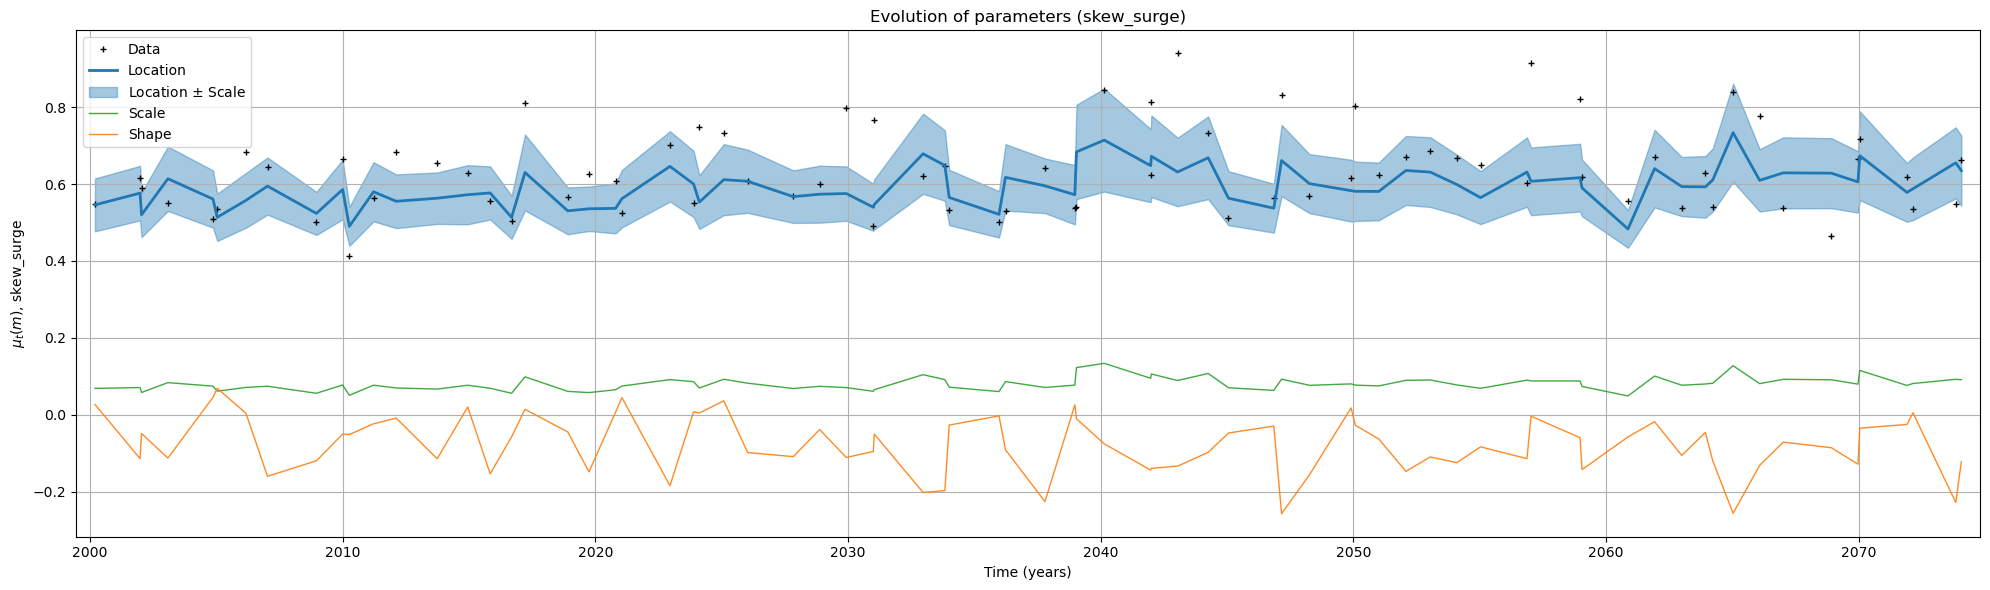

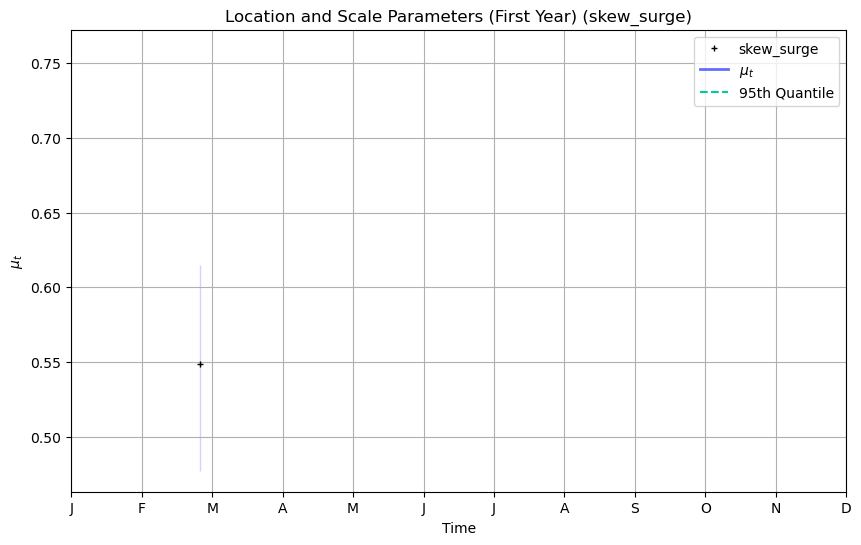

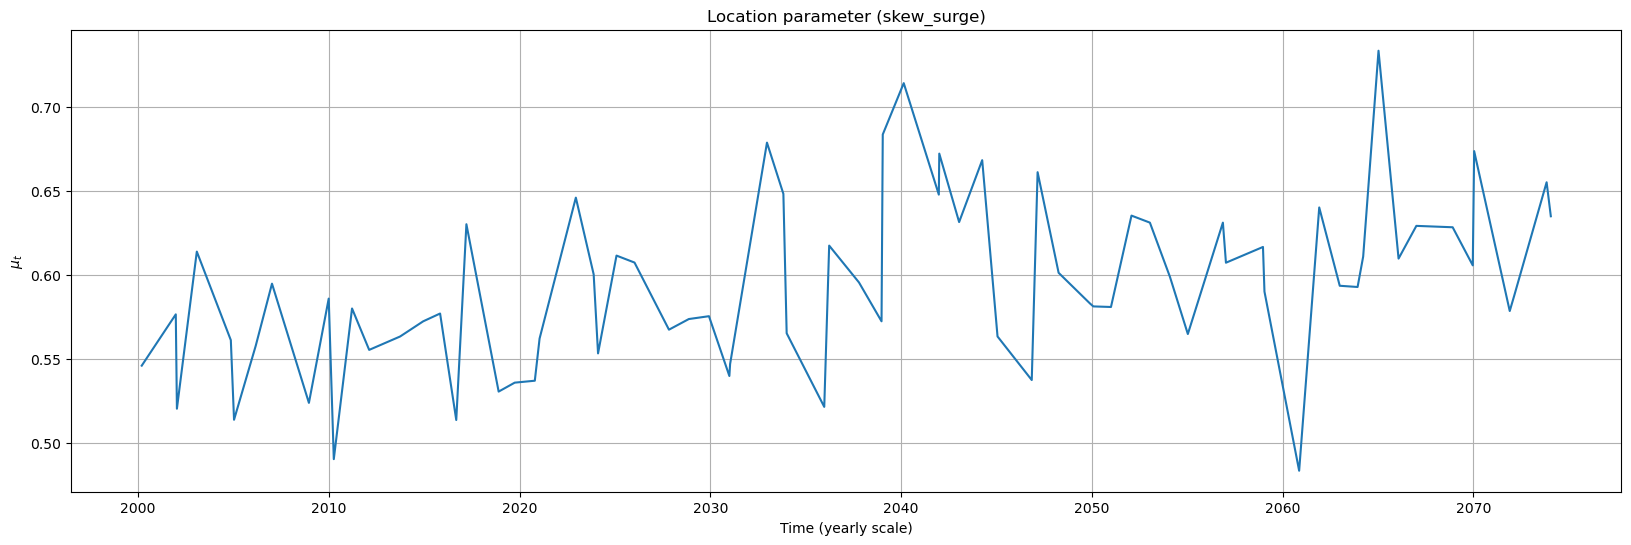

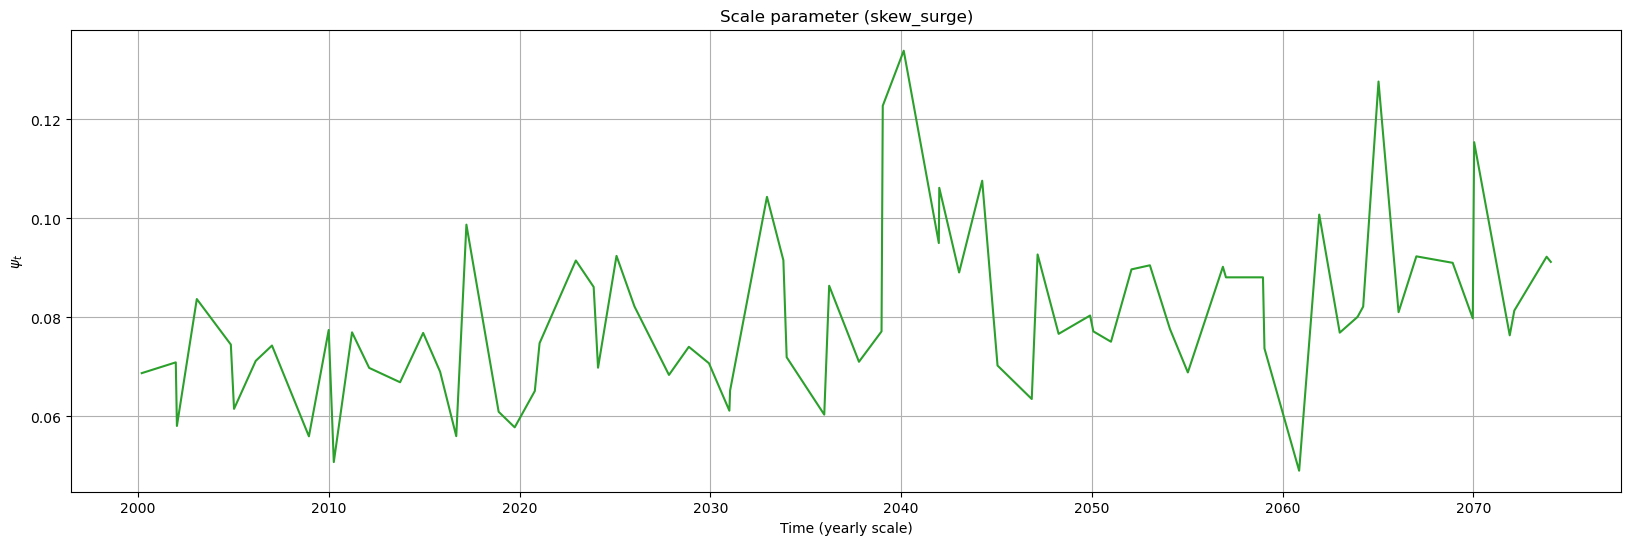

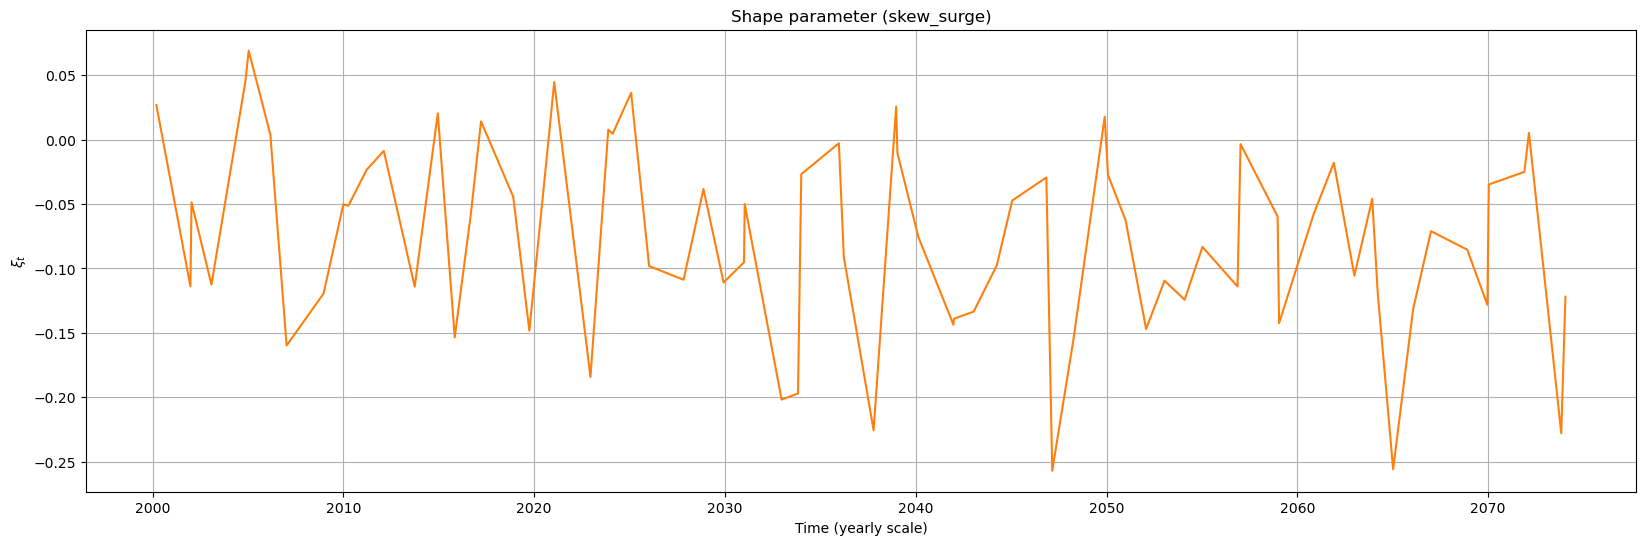

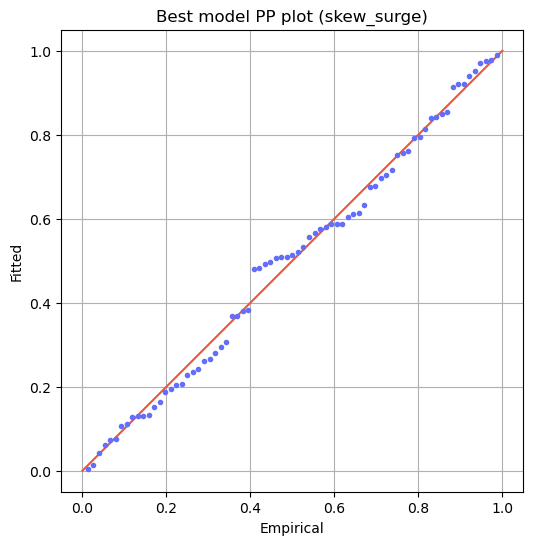

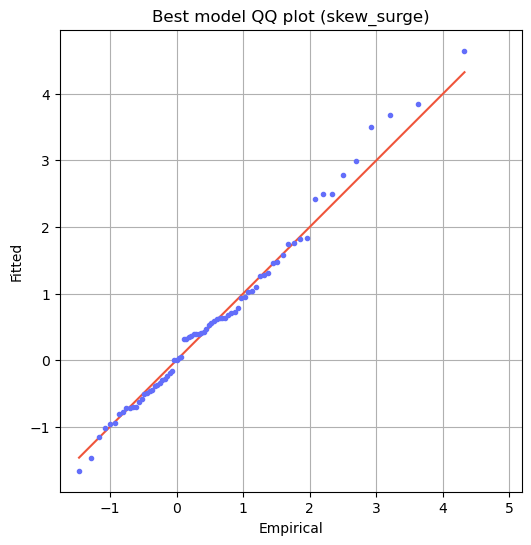

In [ ]:
nonstatgev.plot()

In [86]:
nonstatgev.summary()


Fitted Time-Dependent GEV model for skew_surge

Location Parameters
----------------------------------------------------------------------
Parameter           Estimate      Std. Error           95% CI         
----------------------------------------------------------------------
Beta0                 0.5935          0.0103       [  0.5734,  0.6137]
Beta_cov1             0.0421          0.0114       [  0.0198,  0.0645]
Beta_cov2             0.0256          0.0099       [  0.0063,  0.0449]

Scale Parameters
----------------------------------------------------------------------
Parameter           Estimate      Std. Error           95% CI         
----------------------------------------------------------------------
Alpha0               -2.5428          0.0052       [ -2.5530, -2.5326]
Alpha_cov1            0.1901          0.0937       [  0.0063,  0.3738]
Alpha_cov2            0.0582          0.0929       [ -0.1238,  0.2402]

Shape Parameters
-------------------------------------------

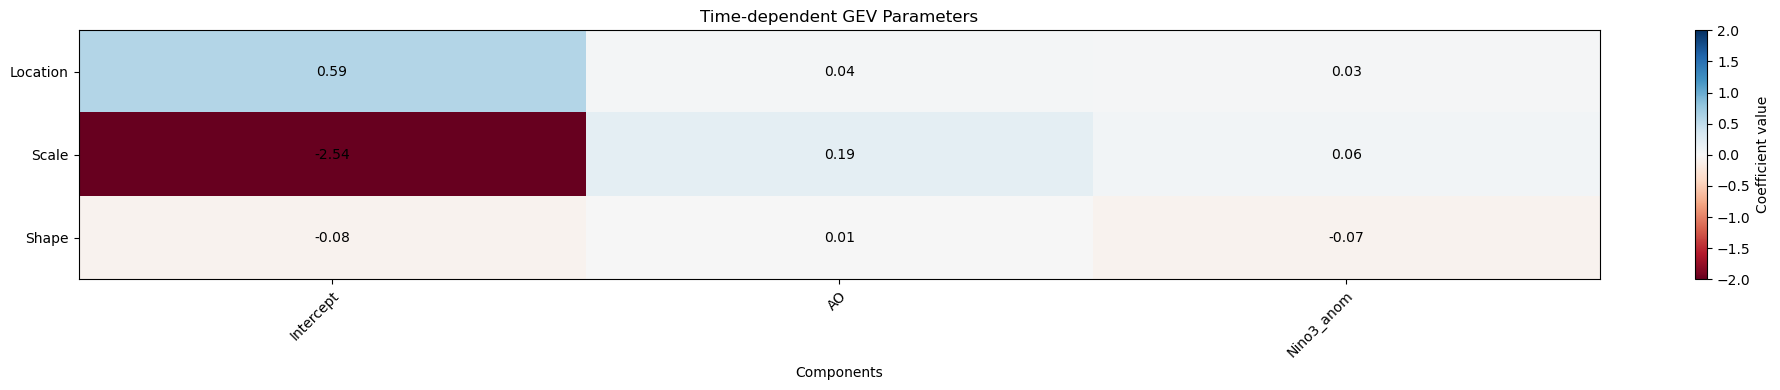

In [87]:
nonstatgev.paramplot()

[       nan        nan        nan        nan        nan        nan
        nan 1.55322986 1.55917781 1.56207909 1.56493404 1.56634462
 1.56718567 1.56830097 1.56885602 1.56940937 1.5696854  1.5701812
 1.57034616]


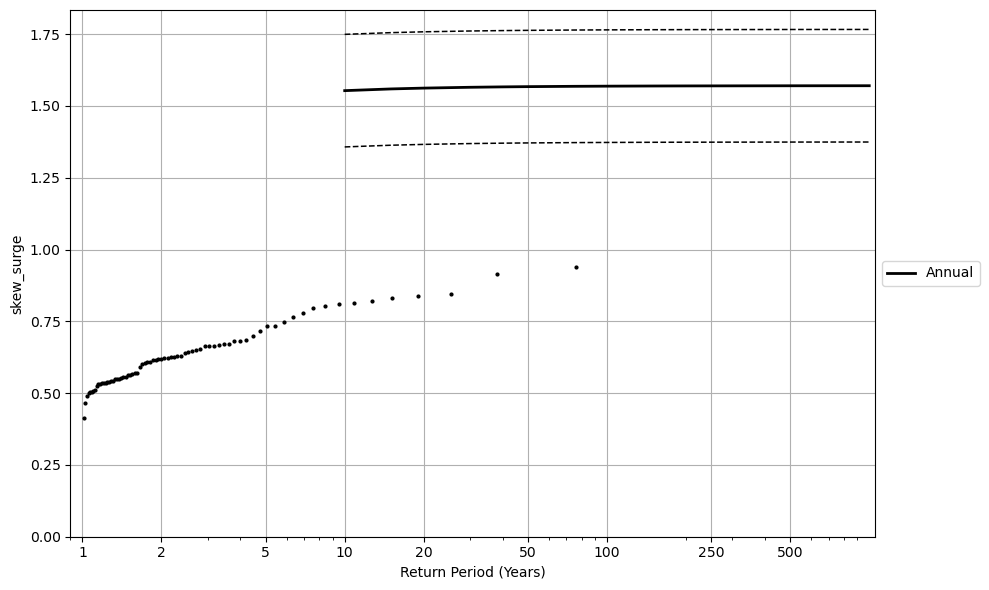

In [88]:
nonstatgev.returnperiod_plot(monthly_plot=False)
